# Efficiency calculation a mixture of radionuclides

## install a stable TDCRPy version

In [1]:
pip install TDCRPy==2.20.11

  Using cached tdcrpy-2.20.11-py3-none-any.whl.metadata (7.9 kB)
Using cached tdcrpy-2.20.11-py3-none-any.whl (23.5 MB)
  Attempting uninstall: TDCRPy
    Found existing installation: TDCRPy 2.20.12
    Uninstalling TDCRPy-2.20.12:
      Successfully uninstalled TDCRPy-2.20.12
Note: you may need to restart the kernel to use updated packages.


## Import modules

In [2]:
import tdcrpy as td
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

## Enter the parameters

In [3]:
mode = "eff"                # ask for efficiency calculation
Rad = "Fe-55, Ni-63"        # list of radionuclides
pmf_1="1"                   # relatives fractions of the radionulides
N = 1000                    # number of Monte Carlo trials
kB =1.0e-5                  # Birks constant in cm keV-1
V = 10                      # volume of scintillator in mL
L=1                         # free parameter in keV-1
C = np.arange(0,1,0.05)     # relative fraction of the second nuclide

## Efficiency calculation for different fractions of the seconde nuclide

In [4]:
effS, ueffS, effD, ueffD, effT, ueffT, effD2, ueffD2 = [], [], [], [], [], [], [], []
for i in tqdm(C, desc="Processing items"):
    pmf_1 = f"{1-i}, {i}"
    result = td.TDCRPy.TDCRPy(L, Rad, pmf_1, N, kB, V, mode)
    effS.append(result[0]); ueffS.append(result[1])
    effD.append(result[2]); ueffD.append(result[3])
    effT.append(result[4]); ueffT.append(result[5])
    effD2.append(result[12]); ueffD2.append(result[13])
effD = np.asarray(effD); ueffD = np.asarray(ueffD)
effD2 = np.asarray(effD2); ueffD2 = np.asarray(ueffD2)
effT = np.asarray(effT); ueffT = np.asarray(ueffT)
TDCR = effT/effD

Processing items:   0%|          | 0/20 [00:00<?, ?it/s]

Processing items:   5%|▌         | 1/20 [00:06<02:09,  6.80s/it]

Processing items:  10%|█         | 2/20 [00:13<01:59,  6.65s/it]

Processing items:  15%|█▌        | 3/20 [00:19<01:51,  6.55s/it]

Processing items:  20%|██        | 4/20 [00:25<01:37,  6.12s/it]

...

Processing items:  85%|████████▌ | 17/20 [01:10<00:06,  2.24s/it]

Processing items:  90%|█████████ | 18/20 [01:11<00:03,  1.89s/it]

Processing items:  95%|█████████▌| 19/20 [01:12<00:01,  1.58s/it]

Processing items: 100%|██████████| 20/20 [01:13<00:00,  1.27s/it]

Processing items: 100%|██████████| 20/20 [01:13<00:00,  3.67s/it]

## Plot the efficiency curves

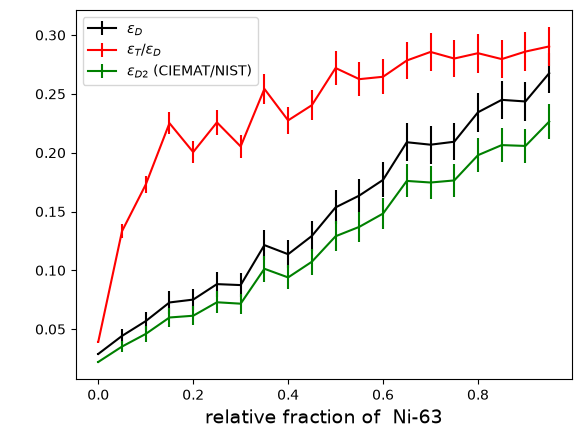

In [5]:
plt.figure("Stopping power")
plt.clf()
plt.errorbar(C,effD,yerr=2*ueffD,fmt="-k",label=r"$\epsilon_D$")
plt.errorbar(C,TDCR,yerr=2*ueffD,fmt="-r",label=r"$\epsilon_T/\epsilon_D$")
plt.errorbar(C,effD2,yerr=2*ueffD2,fmt="-g",label=r"$\epsilon_{D2}$ (CIEMAT/NIST)")
#plt.xscale('log')
plt.xlabel(f'relative fraction of {Rad.split(",")[1]}', fontsize=14)
plt.ylabel(r' ', fontsize=14)
plt.legend()
plt.savefig("stopping_power_plot.png")